In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [2]:
con = duckdb.connect(database='D:/Assets/BinanceFuturesData/binancefuturesdata.duckdb', read_only=True)
query = """
SELECT epoch_ms(timestamp) as time, open, high, low, close, volume 
FROM quote 
WHERE symbol = 'XRPUSDT' 
  AND epoch_ms(timestamp) >= '2022-01-01 00:00:00' 
  AND epoch_ms(timestamp) < '2025-12-01 00:00:00' 
ORDER BY timestamp;
"""
df_raw = con.execute(query).fetchdf()
con.close()

df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw.set_index('time', inplace=True)

resample_rules = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
df = df_raw.resample('15min').agg(resample_rules).dropna().reset_index()

df.shape

(137280, 6)

In [4]:
def add_adaptive_indicators(df, cci_p=32, bb_d=2.8):
    df = df.copy()
    # CCI 기반 볼린저 밴드
    tp = (df['high'] + df['low'] + df['close']) / 3
    sma_tp = tp.rolling(window=cci_p).mean()
    mad_tp = tp.rolling(window=cci_p).apply(lambda x: np.abs(x - x.mean()).mean())
    df['cci'] = (tp - sma_tp) / (0.015 * mad_tp + 1e-8)
    
    df['cci_ma'] = df['cci'].rolling(window=cci_p).mean()
    df['cci_std'] = df['cci'].rolling(window=cci_p).std()
    df['cci_upper'] = df['cci_ma'] + (df['cci_std'] * bb_d)
    df['cci_lower'] = df['cci_ma'] - (df['cci_std'] * bb_d)

    # 일목균형표
    df['tenkan_sen'] = (df['high'].rolling(window=9).max() + df['low'].rolling(window=9).min()) / 2
    df['kijun_sen'] = (df['high'].rolling(window=26).max() + df['low'].rolling(window=26).min()) / 2
    df['senkou_span_a'] = ((df['tenkan_sen'] + df['kijun_sen']) / 2)
    df['senkou_span_b'] = (df['high'].rolling(window=52).max() + df['low'].rolling(window=52).min()) / 2
    
    return df.dropna()

def apply_adaptive_labeling(df, look_ahead=12):
    labels = []
    # 최적화를 위해 numpy 연산 활용
    closes = df['close'].values
    cci = df['cci'].values
    cci_upper = df['cci_upper'].values
    kijun = df['kijun_sen'].values
    
    for i in range(len(df) - look_ahead):
        future_cci = cci[i+1 : i+1+look_ahead]
        future_upper = cci_upper[i+1 : i+1+look_ahead]
        future_close = closes[i+1 : i+1+look_ahead]
        future_kijun = kijun[i+1 : i+1+look_ahead]
        
        # 조건 확인
        tp_idx = np.where(future_cci >= future_upper)[0]
        sl_idx = np.where(future_close <= future_kijun)[0]
        
        first_tp = tp_idx[0] if len(tp_idx) > 0 else 999
        first_sl = sl_idx[0] if len(sl_idx) > 0 else 999
        
        if first_tp < first_sl and first_tp != 999:
            labels.append(1) # Buy
        elif first_sl < first_tp and first_sl != 999:
            labels.append(2) # Sell
        else:
            labels.append(0) # Hold
            
    return np.array(labels)

In [5]:
print("--- 최적 지표 파라미터 탐색 중 ---")
best_params = {'cci_p': 32, 'bb_d': 2.8}
best_score = 0

for p in [24, 32, 40]:
    for d in [2.5, 3.0]:
        temp_df = add_adaptive_indicators(df, cci_p=p, bb_d=d)
        temp_labels = apply_adaptive_labeling(temp_df)
        # Buy/Sell 비중이 적절한지 체크 (전체 신호의 20~40% 사이 선호)
        signal_ratio = np.mean(temp_labels != 0)
        if 0.15 < signal_ratio < 0.45:
            if signal_ratio > best_score:
                best_score = signal_ratio
                best_params = {'cci_p': p, 'bb_d': d}

print(f"최적 파라미터: {best_params}, 신호 비중: {best_score:.2f}")

# 최적 파라미터로 데이터 확정
df = add_adaptive_indicators(df, **best_params)
labels = apply_adaptive_labeling(df)
df = df.iloc[:len(labels)].copy()
df['label'] = labels

--- 최적 지표 파라미터 탐색 중 ---
최적 파라미터: {'cci_p': 32, 'bb_d': 2.8}, 신호 비중: 0.00


In [6]:
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'cci', 'cci_upper', 'cci_lower', 'tenkan_sen', 'kijun_sen', 'senkou_span_a', 'senkou_span_b']
scaler = StandardScaler()

train_idx = int(len(df) * 0.8)
train_df = df.iloc[:train_idx]
test_df = df.iloc[train_idx:]

X_train_scaled = scaler.fit_transform(train_df[feature_cols])
X_test_scaled = scaler.transform(test_df[feature_cols])

def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i : i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24 # 과거 6시간(15분*24) 데이터 참조
X_train, y_train_raw = create_sequences(X_train_scaled, train_df['label'].values, TIME_STEPS)
X_test, y_test_raw = create_sequences(X_test_scaled, test_df['label'].values, TIME_STEPS)

y_train = to_categorical(y_train_raw, 3)
y_test = to_categorical(y_test_raw, 3)

# 클래스 가중치
weights = compute_class_weight('balanced', classes=np.unique(y_train_raw), y=y_train_raw)
class_weights = dict(enumerate(weights))

In [7]:
def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model((TIME_STEPS, len(feature_cols)))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_adaptive_model.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

Epoch 1/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5117 - loss: 0.8928 - val_accuracy: 0.4792 - val_loss: 0.9344
Epoch 2/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5436 - loss: 0.8284 - val_accuracy: 0.4308 - val_loss: 1.0403
Epoch 3/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5522 - loss: 0.8027 - val_accuracy: 0.5229 - val_loss: 0.8856
Epoch 4/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5637 - loss: 0.7805 - val_accuracy: 0.4748 - val_loss: 0.9879
Epoch 5/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5665 - loss: 0.7629 - val_accuracy: 0.5085 - val_loss: 0.8987
Epoch 6/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5714 - loss: 0.7508 - val_accuracy: 0.4806 - val_loss: 0.9520
Epoch 7/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5766 - loss: 0.7360 - val_accuracy: 0.5461 - val_loss: 0.8608
Epoch 8/50
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5831 - loss: 0.7180 - 

In [8]:
pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(y_test, axis=1)

print("\n--- 상세 리포트 ---")
print(classification_report(true_classes, pred_classes, target_names=['Hold', 'Buy', 'Sell']))

# 백테스팅
balance = 10000.0
position = 0
fee = 0.0004
prices = test_df['close'].values[TIME_STEPS:]
portfolio = []

for i in range(len(pred_classes)):
    if pred_classes[i] == 1 and balance > 0: # Buy
        position = (balance * (1 - fee)) / prices[i]
        balance = 0
    elif pred_classes[i] == 2 and position > 0: # Sell
        balance = (position * prices[i]) * (1 - fee)
        position = 0
    portfolio.append(balance + (position * prices[i]))

print(f"최종 자산: ${portfolio[-1]:.2f} (수익률: {((portfolio[-1]-10000)/10000)*100:.2f}%)")

857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- 상세 리포트 ---
              precision    recall  f1-score   support

        Hold       0.46      0.67      0.55      5693
         Buy       0.11      0.64      0.19       943
        Sell       0.91      0.60      0.73     20782

    accuracy                           0.62     27418
   macro avg       0.49      0.64      0.49     27418
weighted avg       0.79      0.62      0.67     27418

최종 자산: $5840.90 (수익률: -41.59%)


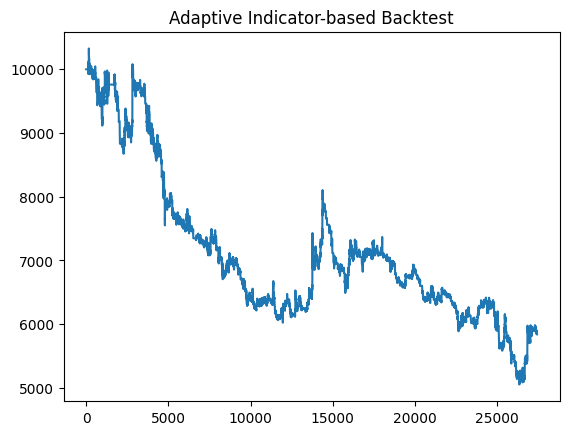

In [9]:
plt.plot(portfolio)
plt.title("Adaptive Indicator-based Backtest")
plt.show()